In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# Load both datasets
game_stats = pd.read_csv('../Cleaned Data/Finished/PlayerStatistics.csv', low_memory=False)
injuries = pd.read_csv('../Cleaned Data/Finished/injury_locations_categorized.csv')

# Keep only 2010-2020
game_stats['gameDate'] = pd.to_datetime(game_stats['gameDate'], errors='coerce')
game_stats = game_stats[
    (game_stats['gameDate'].dt.year >= 2010) &
    (game_stats['gameDate'].dt.year <= 2020)
]

In [15]:
def build_player_week_dataset(game_stats):
    """
    Build a dynamic player-week dataset for injury risk prediction.

    Parameters:
    - game_stats (DataFrame): Player game logs including 'personId', 'gameDate', 'numMinutes', 'points', 'assists', 'reboundsTotal', 'season'

    Returns:
    - player_week_data (DataFrame): Player-week snapshots
    """

    # Step 1: Prepare data
    game_stats = game_stats.copy()
    game_stats['gameDate'] = pd.to_datetime(game_stats['gameDate'])
    game_stats = game_stats.sort_values(['personId', 'gameDate'])

    # New empty list to hold weekly player snapshots
    player_week_snapshots = []

    # Step 2: Loop over each season
    seasons = game_stats['season'].unique()

    for season in seasons:
        season_games = game_stats[game_stats['season'] == season]

        # Set date range for the season
        min_date = season_games['gameDate'].min()
        max_date = season_games['gameDate'].max()

        # Generate weekly cutoff dates (every Monday)
        weekly_cutoffs = pd.date_range(start=min_date, end=max_date, freq='W-MON')

        for cutoff_date in weekly_cutoffs:
            # All games up to this cutoff
            games_until_now = season_games[season_games['gameDate'] <= cutoff_date]

            if games_until_now.empty:
                continue

            # Step 3: Build player summaries up to cutoff
            summary = games_until_now.groupby('personId').agg({
                'firstName': 'first',
                'lastName': 'first',
                'numMinutes': ['count', 'mean'],
                'points': 'mean',
                'assists': 'mean',
                'reboundsTotal': 'mean'
            }).reset_index()

            # Rename columns
            summary.columns = [
                'personId', 'firstName', 'lastName',
                'games_played', 'avg_minutes',
                'avg_points', 'avg_assists', 'avg_rebounds'
            ]

            # Rolling 5-game averages (last 5 games)
            rolling5 = games_until_now.groupby('personId').apply(
                lambda df: df.tail(5).agg({
                    'numMinutes': 'mean',
                    'points': 'mean'
                })
            ).reset_index()

            rolling5.columns = ['personId', 'rolling5_minutes', 'rolling5_points']

            # Back-to-back game counts
            games_until_now['days_since_last_game'] = games_until_now.groupby('personId')['gameDate'].diff().dt.days
            games_until_now['back_to_back_flag'] = (games_until_now['days_since_last_game'] <= 1).astype(int)
            b2b = games_until_now.groupby('personId')['back_to_back_flag'].sum().reset_index()
            b2b.columns = ['personId', 'back_to_back_games']

            # Merge all features
            merged = summary.merge(rolling5, on='personId', how='left')
            merged = merged.merge(b2b, on='personId', how='left')

            # Add season and cutoff date
            merged['season'] = season
            merged['cutoff_date'] = cutoff_date

            # Add to list
            player_week_snapshots.append(merged)

    # Step 4: Combine all snapshots
    player_week_data = pd.concat(player_week_snapshots, ignore_index=True)

    return player_week_data

def infer_season(date):
    year = date.year
    if date.month >= 9: 
        return f"{year}-{year+1}"
    else:
        return f"{year-1}-{year}"

game_stats['gameDate'] = pd.to_datetime(game_stats['gameDate'])  
game_stats['season'] = game_stats['gameDate'].apply(infer_season)


player_week_data = build_player_week_dataset(game_stats)

# Preview
print(player_week_data.head())

KeyError: 'season'

In [3]:
# Summarize per player
player_summary = game_stats.groupby('personId').agg({
    'firstName': 'first',
    'lastName': 'first',
    'numMinutes': ['count', 'mean'],
    'points': 'mean',
    'assists': 'mean',
    'reboundsTotal': 'mean'
}).reset_index()

# Rename columns
player_summary.columns = [
    'personId', 'firstName', 'lastName',
    'games_played', 'avg_minutes',
    'avg_points', 'avg_assists', 'avg_rebounds'
]

# Avoid 1-20 game players
player_summary = player_summary[player_summary['games_played'] >= 20]


In [4]:
# Summarize injuries per player
injury_summary = injuries.groupby('Relinquished').size().reset_index(name='injury_count')

# Merge injury data
player_summary['full_name'] = player_summary['firstName'] + ' ' + player_summary['lastName']
merged = pd.merge(player_summary, injury_summary, how='left', left_on='full_name', right_on='Relinquished')

# Fill missing injuries with 0
merged['injury_count'] = merged['injury_count'].fillna(0)
merged.head()

,personId,firstName,lastName,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,full_name,Relinquished,injury_count
0,255,Grant,Hill,234,26.564103,8.838828,1.835165,3.472527,Grant Hill,Grant Hill,16.0
1,406,Shaquille,O'Neal,80,20.637500,8.968750,0.895833,4.375000,Shaquille O'Neal,Shaquille O'Neal,13.0
2,436,Juwan,Howard,171,13.046784,2.341085,0.341085,1.794574,Juwan Howard,Juwan Howard,1.0
3,467,Jason,Kidd,307,30.309446,7.276190,6.034921,4.400000,Jason Kidd,Jason Kidd,8.0
4,686,Antonio,McDyess,141,19.936170,5.250000,1.098684,5.302632,Antonio McDyess,Antonio McDyess,1.0


In [5]:
features = merged[['games_played', 'avg_minutes', 'avg_points', 'avg_assists', 'avg_rebounds', 'injury_count']]

# Drop NaN players
features = features.dropna()

# Match merged rows to features
merged = merged.loc[features.index].reset_index(drop=True)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

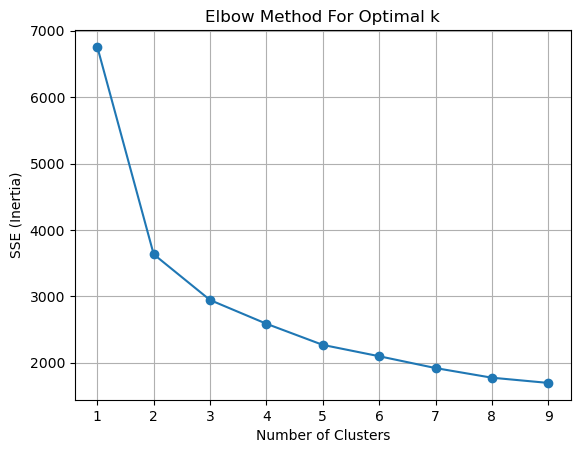

In [7]:
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 10), sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [8]:
# Choose 4 clusters based on elbow
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Assign cluster labels
merged['injury_risk_cluster'] = clusters


In [9]:
# Analyze clusters
cluster_summary = merged.groupby('injury_risk_cluster').mean(numeric_only=True)
display(cluster_summary)

,personId,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,injury_count
injury_risk_cluster,,,,,,,
0,607795.951613,342.973118,21.347030,7.362136,1.496687,3.270150,6.430108
1,706413.907579,103.170055,11.691675,2.687234,0.578927,1.399656,1.933457
2,130389.813725,571.303922,24.850333,9.189281,2.115393,3.779930,32.568627
3,470072.828829,575.567568,30.365844,15.512561,3.696002,5.563334,12.288288


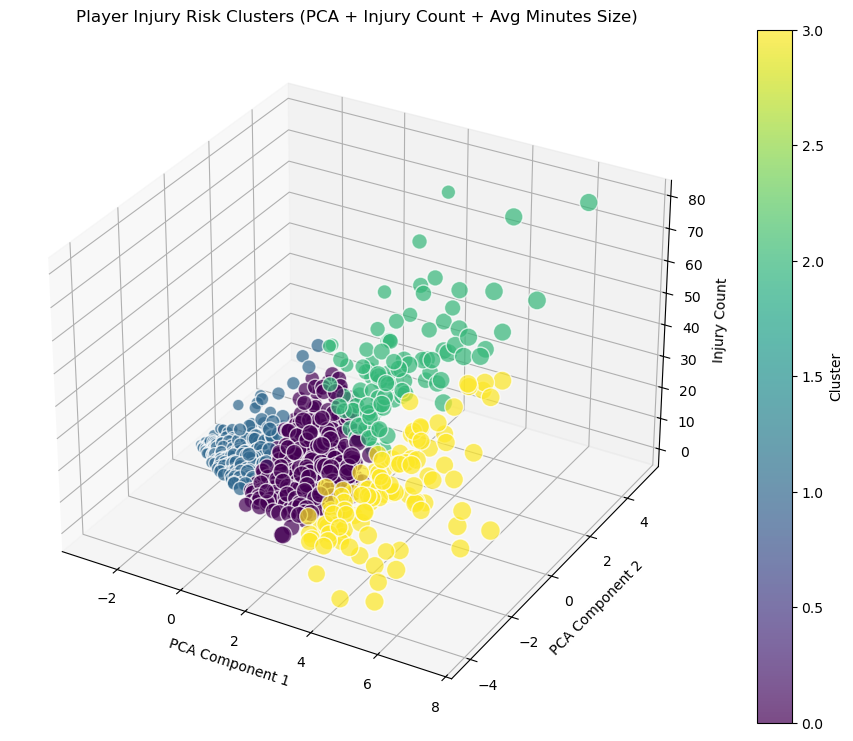

In [10]:
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting

# Reduce features to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add Injury Count as Z-axis
injury_counts = merged['injury_count'].values  
avg_minutes = merged['avg_minutes'].values

# Normalize dot size
size_scaled = (avg_minutes - avg_minutes.min()) / (avg_minutes.max() - avg_minutes.min())
size_scaled = 50 + (size_scaled * 150) 

# Plot
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    injury_counts,
    c=clusters,
    s=size_scaled,
    cmap='viridis',
    alpha=0.7,
    edgecolors='w'
)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('Injury Count')
ax.set_title('Player Injury Risk Clusters (PCA + Injury Count + Avg Minutes Size)')

fig.colorbar(scatter, ax=ax, label='Cluster')
plt.show()


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. Features and Labels
X = merged[['games_played', 'avg_minutes', 'avg_points', 'avg_assists', 'avg_rebounds', 'injury_count']]
y = merged['injury_risk_cluster']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y 
)

# 3. Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 5. Predict
y_pred = knn.predict(X_test_scaled)

# 6. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9513274336283186

Confusion Matrix:
 [[ 69   5   1   0]
 [  2 107   0   0]
 [  1   0  19   0]
 [  0   0   2  20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94        75
           1       0.96      0.98      0.97       109
           2       0.86      0.95      0.90        20
           3       1.00      0.91      0.95        22

    accuracy                           0.95       226
   macro avg       0.94      0.94      0.94       226
weighted avg       0.95      0.95      0.95       226



In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Features and Labels
X = merged[['games_played', 'avg_minutes', 'avg_points', 'avg_assists', 'avg_rebounds', 'injury_count']]
y = merged['injury_risk_cluster']

# 2. Train/Test Split (again)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Train Decision Tree
tree = DecisionTreeClassifier(random_state=42, max_depth=5)
tree.fit(X_train, y_train)

# 4. Predict
y_pred = tree.predict(X_test)

# 5. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8805309734513275

Confusion Matrix:
 [[68  5  2  0]
 [11 98  0  0]
 [ 2  0 17  1]
 [ 3  0  3 16]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86        75
           1       0.95      0.90      0.92       109
           2       0.77      0.85      0.81        20
           3       0.94      0.73      0.82        22

    accuracy                           0.88       226
   macro avg       0.87      0.85      0.85       226
weighted avg       0.89      0.88      0.88       226



In [13]:
import joblib

joblib.dump(knn, 'knn_model.pkl')
joblib.dump(tree, 'decision_tree_model.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


/Users/tymandachit/Documents/SW/MachineLearningProject/Models


['scaler.pkl']